In [1]:
print("Hello")

Hello


In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
df = pd.read_csv("Tweets.csv")
df = df[["text", "airline_sentiment"]]
df.columns = ["text", "label"]
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Tweets.csv'

In [4]:
!ls

sample_data


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets.csv


In [6]:
df = pd.read_csv("Tweets.csv")
df = df[["text", "airline_sentiment"]]
df.columns = ["text", "label"]
df.head()

,text,label
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [7]:
print(df.shape)
print(df["label"].value_counts())

(14640, 2)
label
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


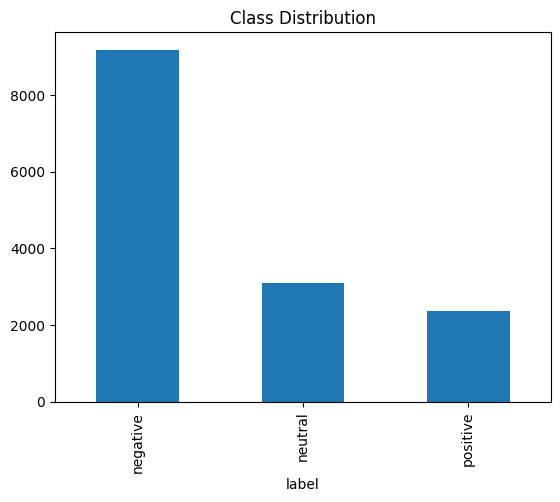

In [8]:
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

In [9]:
lemmatizer = WordNetLemmatizer()
print(lemmatizer.lemmatize("flights"))
print(lemmatizer.lemmatize("running", pos="v"))

flight
run


In [10]:
stop_words = set(stopwords.words("english"))
print(list(stop_words)[:15])
print("not" in stop_words)

["i've", 'these', 'she', "they're", "it'd", "weren't", 'themselves', "i'll", 'weren', 'the', 'few', 'needn', 'now', 'o', 'there']
True


In [11]:
stop_words = set(stopwords.words("english")) - {"no", "not", "nor", "never", "against"}
print("not" in stop_words)
print("the" in stop_words)

False
True


In [15]:
def preprocess(text):
    text = text.lower()                        # sab kuch chhote letters mein
    text = re.sub(r"http\S+", " ", text)       # links hatao
    text = re.sub(r"@\w+", " ", text)          # mention hatao
    text = re.sub(r"n't\b", " not", text)      # don't -> do not
    text = re.sub(r"[^a-z\s]", " ", text)      # numbers, symbols, emoji hatao
    words = text.split()                       # text ko alag alag words mein todo
    words = [w for w in words if w not in stop_words and len(w) > 1]   # stop-words hatao
    words = [lemmatizer.lemmatize(w) for w in words]                   # lemmatize (noun)
    words = [lemmatizer.lemmatize(w, pos="v") for w in words]          # lemmatize (verb)
    return " ".join(words)                     # words wapas jor do

In [16]:
print(preprocess("@united I don't like the flight delays!! http://t.co/abc"))

not like flight delay


In [17]:
df["clean"] = df["text"].apply(preprocess)
df[["text", "clean"]].head(10)

,text,clean
0,@VirginAmerica What @dhepburn said.,say
1,@VirginAmerica plus you've added commercials t...,plus add commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,not today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat not play reall...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly vx ear worm go away
7,@VirginAmerica Really missed a prime opportuni...,really miss prime opportunity men without hat ...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well not
9,"@VirginAmerica it was amazing, and arrived an ...",amaze arrive hour early good


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(len(X_train), len(X_test))

11712 2928


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(11712, 5000)
(2928, 5000)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(y_pred[:10])

['negative' 'neutral' 'negative' 'negative' 'negative' 'negative'
 'neutral' 'negative' 'negative' 'neutral']


In [21]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred, digits=4))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

              precision    recall  f1-score   support

    negative     0.8969    0.8011    0.8463      1835
     neutral     0.5381    0.6952    0.6066       620
    positive     0.6680    0.6892    0.6785       473

    accuracy                         0.7606      2928
   macro avg     0.7010    0.7285    0.7105      2928
weighted avg     0.7839    0.7606    0.7684      2928

Macro F1: 0.7104538995303492
Weighted F1: 0.7684251995468924


Logistic Regression -> 0.7105
Linear SVM -> 0.7053
Naive Bayes -> 0.5313


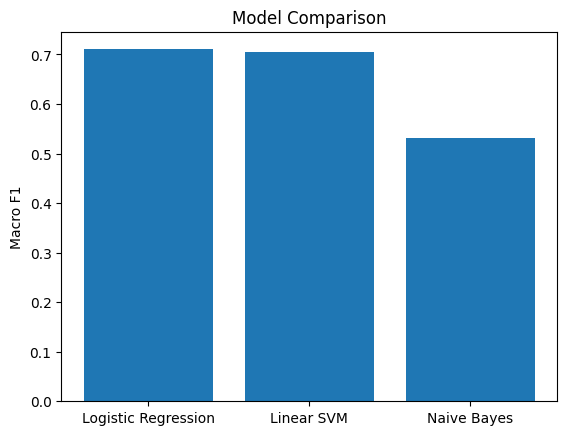

In [22]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
}

results = {}
for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    pred = clf.predict(X_test_tfidf)
    results[name] = f1_score(y_test, pred, average="macro")
    print(name, "->", round(results[name], 4))

plt.bar(results.keys(), results.values())
plt.ylabel("Macro F1")
plt.title("Model Comparison")
plt.show()

In [23]:
best_name = "Linear SVM"        # yahan apne best model ka naam likhein
best_model = models[best_name]
y_pred = best_model.predict(X_test_tfidf)
print(best_name, "->", f1_score(y_test, y_pred, average="macro"))

Linear SVM -> 0.7053292617206331


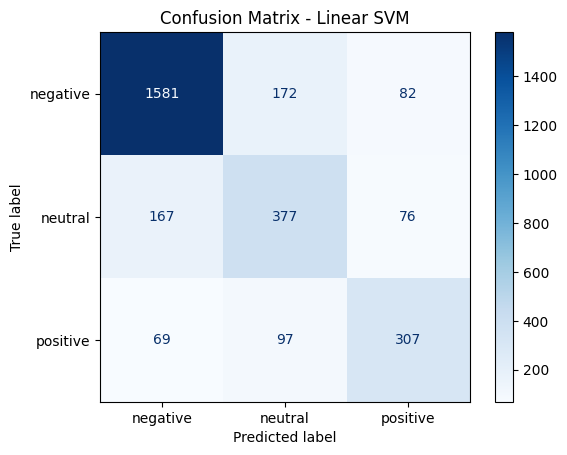

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - " + best_name)
plt.show()

In [25]:
def predict_sentiment(text):
    clean = preprocess(text)
    numbers = tfidf.transform([clean])
    return best_model.predict(numbers)[0]

print(predict_sentiment("The crew was amazing and very kind"))
print(predict_sentiment("This is not good, I waited for hours"))
print(predict_sentiment("My flight is at 5 pm tomorrow"))

positive
negative
neutral


In [26]:
import joblib
joblib.dump((tfidf, best_model), "sentiment_model.joblib")

['sentiment_model.joblib']